## Number Processing

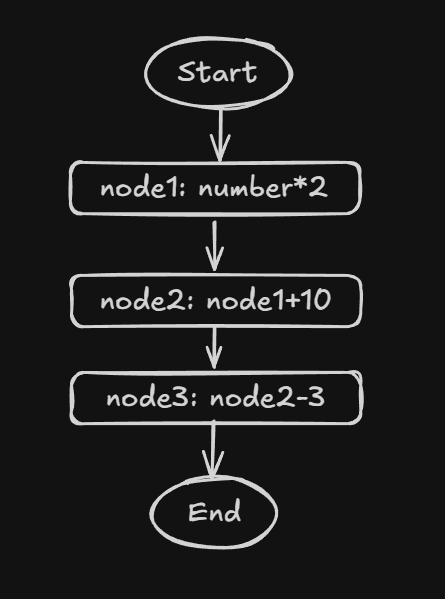

In [41]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [42]:
class AgentState(TypedDict):
    number : int
    result : int

In [43]:
def node1(state: AgentState) -> AgentState:
    """This node performs multiplication with the input number."""
    state['result'] = state['number'] * 2
    print(state['result'])
    return state

def node2(state: AgentState) -> AgentState:
    """"This node adds 10 to the result from the previous node."""
    state['result'] = state['result'] + 10
    print(state['result'])
    return state

def node3(state: AgentState) -> AgentState:
    """This node subtracts 3 from the result of the previous node."""
    state['result'] = state['result'] - 3
    print(state['result'])
    return state

In [44]:
graph = StateGraph(AgentState)

graph.add_node('node1', node1)
graph.add_node('node2', node2)
graph.add_node('node3', node3)

graph.add_edge('node1', 'node2')
graph.add_edge('node2', 'node3')

graph.set_entry_point('node1')
graph.set_finish_point('node3')

app = graph.compile()

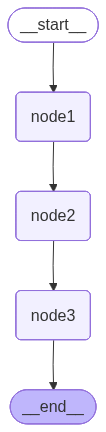

In [45]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [46]:
app.invoke({'number': 5})

10
20
17


{'number': 5, 'result': 17}